# Self-Supervised Handwriting Pretraining

This notebook establishes a self-supervised representation-learning baseline on the QUWI development split.

## Purpose

Previous experiments used writer labels to optimize classification or metric-learning objectives.

This experiment removes writer supervision during representation learning.

The encoder will learn from augmented views of handwriting images only.

## Self-supervised training data

- Development-training writers only
- 226 writers
- 904 handwriting images
- Arabic and English pages
- Variable-text and same-text pages
- No validation images
- No official-test images
- No writer labels used by the self-supervised objective

Using all four development pages exposes the encoder to both scripts and text conditions during unlabeled domain adaptation.

## Method

A MoCo-style contrastive-learning baseline will be used.

Each handwriting image is transformed into two independently augmented views:

- One view is processed by a trainable query encoder
- The other view is processed by an exponential-moving-average key encoder
- The two representations form a positive pair
- A memory queue provides negative representations from other images

This design allows contrastive learning with a small GPU batch size because the number of negatives is not limited to the current mini-batch.

## Controlled encoder setup

- ResNet-18 initialized from ImageNet
- Early backbone frozen
- Layer 4 trainable
- BatchNorm running statistics frozen
- 512-dimensional backbone representation
- Small projection head used only during self-supervised training
- Cosine-normalized contrastive representations
- Validation writer-verification ROC-AUC used for model selection
- Official-test writers remain excluded from model selection

## Evaluation

After self-supervised pretraining:

1. The projection head will be discarded
2. The 512-dimensional backbone embedding will be extracted
3. The fixed writer-disjoint verification protocol will be used
4. Validation ROC-AUC and EER will be measured
5. Within-script and cross-script performance will be analyzed

The primary question is whether unlabeled handwriting-domain adaptation improves transferable writer representation, particularly across scripts.

In [1]:
import copy
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, roc_curve
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import ResNet18_Weights, resnet18

from handwriting_cross_script_research import (
    QUWIDataset,
    load_image_tensor,
)

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path.cwd().resolve()

while PROJECT_ROOT != PROJECT_ROOT.parent and not (
    PROJECT_ROOT / "pyproject.toml"
).exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

assert (PROJECT_ROOT / "pyproject.toml").exists()

IMAGE_DIR = (
    Path.home()
    / "Documents"
    / "Handwriting"
    / "QUWI"
    / "extracted"
    / "images"
)

SPLIT_PATH = (
    PROJECT_ROOT
    / "splits"
    / "quwi_writer_disjoint_split_seed42.csv"
)

VALIDATION_PAIR_PATH = (
    PROJECT_ROOT
    / "splits"
    / "verification"
    / "quwi_validation_verification_pairs.csv"
)

TEST_PAIR_PATH = (
    PROJECT_ROOT
    / "splits"
    / "verification"
    / "quwi_official_test_verification_pairs.csv"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "checkpoints"
    / "self_supervised_pretraining"
)

REPORT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "self_supervised_pretraining"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

split_df = pd.read_csv(
    SPLIT_PATH
)

development_df = (
    split_df[
        split_df["experiment_split"]
        == "development_train"
    ]
    .sort_values(
        [
            "writer",
            "page_id",
        ]
    )
    .reset_index(drop=True)
)

validation_df = split_df[
    split_df["experiment_split"]
    == "validation"
].copy()

test_df = split_df[
    split_df["experiment_split"]
    == "official_test"
].copy()

development_condition_summary_df = (
    development_df
    .groupby(
        [
            "language",
            "same_text",
        ],
        as_index=False,
    )
    .agg(
        images=(
            "filename",
            "size",
        ),
        writers=(
            "writer",
            "nunique",
        ),
    )
)

print(
    "Development SSL images:",
    len(development_df),
)

print(
    "Development writers:",
    development_df[
        "writer"
    ].nunique(),
)

print(
    "Languages:",
    development_df[
        "language"
    ].value_counts().to_dict(),
)

print(
    "Same-text labels:",
    development_df[
        "same_text"
    ].value_counts().sort_index().to_dict(),
)

print(
    "Validation writers:",
    validation_df[
        "writer"
    ].nunique(),
)

print(
    "Official-test writers:",
    test_df[
        "writer"
    ].nunique(),
)

print(
    "Device:",
    DEVICE,
)

if DEVICE.type == "cuda":
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )

display(
    development_condition_summary_df
)

assert len(
    development_df
) == 904

assert development_df[
    "writer"
].nunique() == 226

assert development_df[
    "page_id"
].nunique() == 4

assert validation_df[
    "writer"
].nunique() == 56

assert test_df[
    "writer"
].nunique() == 193

Development SSL images: 904
Development writers: 226
Languages: {'Arabic': 452, 'English': 452}
Same-text labels: {0: 452, 1: 452}
Validation writers: 56
Official-test writers: 193
Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


,language,same_text,images,writers
0,Arabic,0,226,226
1,Arabic,1,226,226
2,English,0,226,226
3,English,1,226,226


In [3]:
ssl_transform = transforms.Compose(
    [
        transforms.RandomResizedCrop(
            size=384,
            scale=(
                0.70,
                1.00,
            ),
            ratio=(
                0.85,
                1.15,
            ),
            antialias=True,
        ),
        transforms.RandomAffine(
            degrees=3,
            translate=(
                0.02,
                0.02,
            ),
            scale=(
                0.95,
                1.05,
            ),
            fill=1.0,
        ),
        transforms.RandomApply(
            [
                transforms.ColorJitter(
                    brightness=0.10,
                    contrast=0.10,
                    saturation=0.05,
                )
            ],
            p=0.40,
        ),
        transforms.RandomApply(
            [
                transforms.GaussianBlur(
                    kernel_size=5,
                    sigma=(
                        0.10,
                        1.00,
                    ),
                )
            ],
            p=0.20,
        ),
    ]
)


class SSLHandwritingDataset(Dataset):
    def __init__(
        self,
        metadata,
        image_dir,
        transform,
    ):
        self.metadata = (
            metadata
            .reset_index(drop=True)
            .copy()
        )

        self.image_dir = Path(
            image_dir
        )

        self.transform = transform

    def __len__(self):
        return len(
            self.metadata
        )

    def __getitem__(
        self,
        index,
    ):
        row = self.metadata.iloc[
            index
        ]

        image, _ = load_image_tensor(
            self.image_dir
            / row["filename"]
        )

        view_q = self.transform(
            image
        )

        view_k = self.transform(
            image
        )

        return {
            "view_q": view_q,
            "view_k": view_k,
            "filename": row[
                "filename"
            ],
        }


ssl_dataset = SSLHandwritingDataset(
    development_df,
    IMAGE_DIR,
    ssl_transform,
)

sample = ssl_dataset[
    0
]

print(
    "SSL dataset size:",
    len(
        ssl_dataset
    ),
)

print(
    "Query-view shape:",
    sample[
        "view_q"
    ].shape,
)

print(
    "Key-view shape:",
    sample[
        "view_k"
    ].shape,
)

print(
    "Query range:",
    round(
        sample[
            "view_q"
        ].min().item(),
        6,
    ),
    "to",
    round(
        sample[
            "view_q"
        ].max().item(),
        6,
    ),
)

print(
    "Key range:",
    round(
        sample[
            "view_k"
        ].min().item(),
        6,
    ),
    "to",
    round(
        sample[
            "view_k"
        ].max().item(),
        6,
    ),
)

print(
    "Views identical:",
    torch.equal(
        sample[
            "view_q"
        ],
        sample[
            "view_k"
        ],
    ),
)

print(
    "Filename:",
    sample[
        "filename"
    ],
)

assert len(
    ssl_dataset
) == 904

assert sample[
    "view_q"
].shape == (
    3,
    384,
    384,
)

assert sample[
    "view_k"
].shape == (
    3,
    384,
    384,
)

assert torch.isfinite(
    sample[
        "view_q"
    ]
).all()

assert torch.isfinite(
    sample[
        "view_k"
    ]
).all()

SSL dataset size: 904
Query-view shape: torch.Size([3, 384, 384])
Key-view shape: torch.Size([3, 384, 384])
Query range: 0.316593 to 1.0
Key range: 0.367622 to 0.920829
Views identical: False
Filename: 0001_1.jpg


In [4]:
SSL_BATCH_SIZE = 8
SSL_NUM_WORKERS = 0

ssl_generator = (
    torch.Generator()
    .manual_seed(SEED)
)

ssl_loader = DataLoader(
    ssl_dataset,
    batch_size=SSL_BATCH_SIZE,
    shuffle=True,
    num_workers=SSL_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    drop_last=True,
    generator=ssl_generator,
)

ssl_batch = next(
    iter(ssl_loader)
)

print(
    "SSL batches per epoch:",
    len(ssl_loader),
)

print(
    "Query batch shape:",
    ssl_batch[
        "view_q"
    ].shape,
)

print(
    "Key batch shape:",
    ssl_batch[
        "view_k"
    ].shape,
)

print(
    "Batch filenames:",
    ssl_batch[
        "filename"
    ][:4],
)

print(
    "Query batch finite:",
    torch.isfinite(
        ssl_batch[
            "view_q"
        ]
    ).all().item(),
)

print(
    "Key batch finite:",
    torch.isfinite(
        ssl_batch[
            "view_k"
        ]
    ).all().item(),
)

assert len(
    ssl_loader
) == 113

assert ssl_batch[
    "view_q"
].shape == (
    8,
    3,
    384,
    384,
)

assert ssl_batch[
    "view_k"
].shape == (
    8,
    3,
    384,
    384,
)

SSL batches per epoch: 113
Query batch shape: torch.Size([8, 3, 384, 384])
Key batch shape: torch.Size([8, 3, 384, 384])
Batch filenames: ['0078_1.jpg', '0193_4.jpg', '0198_3.jpg', '0208_3.jpg']
Query batch finite: True
Key batch finite: True


In [5]:
IMAGENET_MEAN = (
    0.485,
    0.456,
    0.406,
)

IMAGENET_STD = (
    0.229,
    0.224,
    0.225,
)

PROJECTION_DIM = 128
QUEUE_SIZE = 2048
MOCO_MOMENTUM = 0.999
TEMPERATURE = 0.20


class SSLResNetEncoder(nn.Module):
    def __init__(
        self,
        projection_dim,
    ):
        super().__init__()

        backbone = resnet18(
            weights=ResNet18_Weights.DEFAULT
        )

        feature_dim = (
            backbone.fc.in_features
        )

        backbone.fc = nn.Identity()

        self.backbone = backbone

        self.projector = nn.Sequential(
            nn.Linear(
                feature_dim,
                256,
            ),
            nn.ReLU(),
            nn.Linear(
                256,
                projection_dim,
            ),
        )

        self.register_buffer(
            "normalization_mean",
            torch.tensor(
                IMAGENET_MEAN
            ).view(
                1,
                3,
                1,
                1,
            ),
        )

        self.register_buffer(
            "normalization_std",
            torch.tensor(
                IMAGENET_STD
            ).view(
                1,
                3,
                1,
                1,
            ),
        )

        for parameter in (
            self.backbone.parameters()
        ):
            parameter.requires_grad = False

        for parameter in (
            self.backbone
            .layer4
            .parameters()
        ):
            parameter.requires_grad = True

    def train(
        self,
        mode=True,
    ):
        super().train(mode)

        self.backbone.eval()
        self.projector.train(mode)

        return self

    def encode(
        self,
        images,
    ):
        images = (
            images
            - self.normalization_mean
        ) / self.normalization_std

        features = self.backbone(
            images
        )

        features = F.normalize(
            features,
            p=2,
            dim=1,
        )

        return features

    def forward(
        self,
        images,
    ):
        features = self.encode(
            images
        )

        projections = self.projector(
            features
        )

        return F.normalize(
            projections,
            p=2,
            dim=1,
        )


class HandwritingMoCo(nn.Module):
    def __init__(
        self,
        projection_dim,
        queue_size,
        momentum,
        temperature,
    ):
        super().__init__()

        self.encoder_q = SSLResNetEncoder(
            projection_dim
        )

        self.encoder_k = copy.deepcopy(
            self.encoder_q
        )

        for parameter in (
            self.encoder_k.parameters()
        ):
            parameter.requires_grad = False

        self.momentum = momentum
        self.temperature = temperature

        queue = torch.randn(
            projection_dim,
            queue_size,
        )

        queue = F.normalize(
            queue,
            p=2,
            dim=0,
        )

        self.register_buffer(
            "queue",
            queue,
        )

        self.register_buffer(
            "queue_ptr",
            torch.zeros(
                1,
                dtype=torch.long,
            ),
        )

    @torch.no_grad()
    def momentum_update(self):
        for parameter_q, parameter_k in zip(
            self.encoder_q.parameters(),
            self.encoder_k.parameters(),
        ):
            parameter_k.data.mul_(
                self.momentum
            ).add_(
                parameter_q.data,
                alpha=(
                    1.0
                    - self.momentum
                ),
            )

    @torch.no_grad()
    def enqueue(
        self,
        keys,
    ):
        batch_size = keys.shape[
            0
        ]

        pointer = int(
            self.queue_ptr.item()
        )

        end = (
            pointer
            + batch_size
        )

        if end <= self.queue.shape[1]:
            self.queue[
                :,
                pointer:end,
            ] = keys.T
        else:
            first = (
                self.queue.shape[1]
                - pointer
            )

            self.queue[
                :,
                pointer:,
            ] = keys[
                :first
            ].T

            remaining = (
                batch_size
                - first
            )

            self.queue[
                :,
                :remaining,
            ] = keys[
                first:
            ].T

        self.queue_ptr[0] = (
            end
            % self.queue.shape[1]
        )

    def contrastive_logits(
        self,
        query,
        key,
    ):
        positive_logits = torch.sum(
            query * key,
            dim=1,
            keepdim=True,
        )

        negative_logits = torch.matmul(
            query,
            self.queue.detach(),
        )

        logits = torch.cat(
            [
                positive_logits,
                negative_logits,
            ],
            dim=1,
        )

        logits = (
            logits
            / self.temperature
        )

        labels = torch.zeros(
            logits.shape[0],
            dtype=torch.long,
            device=logits.device,
        )

        return (
            logits,
            labels,
        )


moco_model = HandwritingMoCo(
    projection_dim=PROJECTION_DIM,
    queue_size=QUEUE_SIZE,
    momentum=MOCO_MOMENTUM,
    temperature=TEMPERATURE,
).to(DEVICE)

optimizer = torch.optim.AdamW(
    [
        parameter
        for parameter in (
            moco_model
            .encoder_q
            .parameters()
        )
        if parameter.requires_grad
    ],
    lr=1e-5,
    weight_decay=1e-4,
)

moco_model.train()

query_images = ssl_batch[
    "view_q"
].to(
    DEVICE,
    non_blocking=True,
)

key_images = ssl_batch[
    "view_k"
].to(
    DEVICE,
    non_blocking=True,
)

if DEVICE.type == "cuda":
    torch.cuda.reset_peak_memory_stats()

query_projection = (
    moco_model.encoder_q(
        query_images
    )
)

with torch.no_grad():
    key_projection = (
        moco_model.encoder_k(
            key_images
        )
    )

logits, labels = (
    moco_model.contrastive_logits(
        query_projection,
        key_projection,
    )
)

smoke_loss = F.cross_entropy(
    logits,
    labels,
)

optimizer.zero_grad(
    set_to_none=True
)

smoke_loss.backward()

layer4_grad_norm = (
    torch.nn.utils.clip_grad_norm_(
        moco_model
        .encoder_q
        .backbone
        .layer4
        .parameters(),
        max_norm=5.0,
    )
)

projector_grad_norm = (
    torch.nn.utils.clip_grad_norm_(
        moco_model
        .encoder_q
        .projector
        .parameters(),
        max_norm=5.0,
    )
)

peak_memory_mb = (
    torch.cuda.max_memory_allocated()
    / 1024**2
    if DEVICE.type == "cuda"
    else 0.0
)

optimizer.zero_grad(
    set_to_none=True
)

print(
    "Query projection shape:",
    query_projection.shape,
)

print(
    "Key projection shape:",
    key_projection.shape,
)

print(
    "Logit shape:",
    logits.shape,
)

print(
    "Queue shape:",
    moco_model.queue.shape,
)

print(
    "Queue pointer:",
    moco_model.queue_ptr.item(),
)

print(
    "Smoke loss:",
    round(
        smoke_loss.item(),
        6,
    ),
)

print(
    "Layer4 gradient norm:",
    round(
        layer4_grad_norm.item(),
        6,
    ),
)

print(
    "Projector gradient norm:",
    round(
        projector_grad_norm.item(),
        6,
    ),
)

print(
    "Finite loss:",
    torch.isfinite(
        smoke_loss
    ).item(),
)

print(
    "Peak GPU memory:",
    round(
        peak_memory_mb,
        2,
    ),
    "MB",
)

print(
    "Query layer4 training flag:",
    moco_model
    .encoder_q
    .backbone
    .layer4
    .training,
)

assert query_projection.shape == (
    8,
    128,
)

assert key_projection.shape == (
    8,
    128,
)

assert logits.shape == (
    8,
    2049,
)

assert torch.isfinite(
    smoke_loss
)

assert layer4_grad_norm.item() > 0
assert projector_grad_norm.item() > 0

assert (
    moco_model
    .encoder_q
    .backbone
    .layer4
    .training
    is False
)

Query projection shape: torch.Size([8, 128])
Key projection shape: torch.Size([8, 128])
Logit shape: torch.Size([8, 2049])
Queue shape: torch.Size([128, 2048])
Queue pointer: 0
Smoke loss: 2.791992
Layer4 gradient norm: 0.283318
Projector gradient norm: 0.470784
Finite loss: True
Peak GPU memory: 308.8 MB
Query layer4 training flag: False


In [6]:
moco_model.train()

query_bn = (
    moco_model
    .encoder_q
    .backbone
    .layer4[0]
    .bn1
)

bn_mean_before = (
    query_bn
    .running_mean
    .detach()
    .clone()
)

with torch.no_grad():
    _ = moco_model.encoder_q(
        query_images
    )

bn_mean_after = (
    query_bn
    .running_mean
    .detach()
    .clone()
)

query_key_equal = all(
    torch.equal(
        parameter_q.detach(),
        parameter_k.detach(),
    )
    for parameter_q, parameter_k in zip(
        moco_model
        .encoder_q
        .parameters(),
        moco_model
        .encoder_k
        .parameters(),
    )
)

key_trainable_parameters = sum(
    parameter.numel()
    for parameter in (
        moco_model
        .encoder_k
        .parameters()
    )
    if parameter.requires_grad
)

query_trainable_parameters = sum(
    parameter.numel()
    for parameter in (
        moco_model
        .encoder_q
        .parameters()
    )
    if parameter.requires_grad
)

print(
    "Query trainable parameters:",
    query_trainable_parameters,
)

print(
    "Key trainable parameters:",
    key_trainable_parameters,
)

print(
    "Query/key parameters identical:",
    query_key_equal,
)

print(
    "BatchNorm running mean unchanged:",
    torch.equal(
        bn_mean_before,
        bn_mean_after,
    ),
)

print(
    "Queue pointer before training:",
    moco_model.queue_ptr.item(),
)

print(
    "Query layer4 training flag:",
    moco_model
    .encoder_q
    .backbone
    .layer4
    .training,
)

print(
    "Key layer4 training flag:",
    moco_model
    .encoder_k
    .backbone
    .layer4
    .training,
)

assert query_trainable_parameters > 0
assert key_trainable_parameters == 0
assert query_key_equal
assert torch.equal(
    bn_mean_before,
    bn_mean_after,
)
assert moco_model.queue_ptr.item() == 0
assert (
    moco_model
    .encoder_q
    .backbone
    .layer4
    .training
    is False
)

Query trainable parameters: 8557952
Key trainable parameters: 0
Query/key parameters identical: True
BatchNorm running mean unchanged: True
Queue pointer before training: 0
Query layer4 training flag: False
Key layer4 training flag: False


In [7]:
validation_pairs_df = pd.read_csv(
    VALIDATION_PAIR_PATH
)

validation_dataset = QUWIDataset(
    metadata=validation_df,
    image_dir=IMAGE_DIR,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)


@torch.inference_mode()
def extract_backbone_embeddings(
    encoder,
    loader,
):
    encoder.eval()

    filenames = []
    embedding_batches = []

    for batch in loader:
        images = batch[
            "image"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        embeddings = encoder.encode(
            images
        )

        embedding_batches.append(
            embeddings.cpu()
        )

        filenames.extend(
            batch["filename"]
        )

    return (
        filenames,
        torch.cat(
            embedding_batches,
            dim=0,
        ),
    )


def score_pairs(
    pair_df,
    filenames,
    embeddings,
):
    filename_to_index = {
        filename: index
        for index, filename
        in enumerate(
            filenames
        )
    }

    index_a = torch.tensor(
        [
            filename_to_index[
                filename
            ]
            for filename
            in pair_df[
                "filename_a"
            ]
        ],
        dtype=torch.long,
    )

    index_b = torch.tensor(
        [
            filename_to_index[
                filename
            ]
            for filename
            in pair_df[
                "filename_b"
            ]
        ],
        dtype=torch.long,
    )

    return (
        embeddings[
            index_a
        ]
        * embeddings[
            index_b
        ]
    ).sum(
        dim=1
    ).numpy()


def verification_metrics(
    labels,
    scores,
):
    labels = np.asarray(
        labels
    )

    scores = np.asarray(
        scores
    )

    auc = roc_auc_score(
        labels,
        scores,
    )

    fpr, tpr, thresholds = roc_curve(
        labels,
        scores,
        pos_label=1,
    )

    fnr = 1.0 - tpr

    difference = (
        fpr - fnr
    )

    eer = np.interp(
        0.0,
        difference,
        fpr,
    )

    eer_threshold = np.interp(
        0.0,
        difference,
        thresholds,
    )

    return {
        "roc_auc": float(
            auc
        ),
        "eer": float(
            eer
        ),
        "eer_percent": float(
            eer * 100
        ),
        "eer_threshold": float(
            eer_threshold
        ),
    }


validation_filenames, epoch0_embeddings = (
    extract_backbone_embeddings(
        moco_model.encoder_q,
        validation_loader,
    )
)

epoch0_scores = score_pairs(
    validation_pairs_df,
    validation_filenames,
    epoch0_embeddings,
)

epoch0_metrics = verification_metrics(
    validation_pairs_df[
        "pair_label"
    ].to_numpy(),
    epoch0_scores,
)

print(
    "Validation embeddings:",
    epoch0_embeddings.shape,
)

print(
    "Validation verification scores:",
    len(
        epoch0_scores
    ),
)

print(
    "Epoch-0 ROC-AUC:",
    round(
        epoch0_metrics[
            "roc_auc"
        ],
        6,
    ),
)

print(
    "Epoch-0 EER:",
    round(
        epoch0_metrics[
            "eer_percent"
        ],
        4,
    ),
    "%",
)

print(
    "Epoch-0 EER threshold:",
    round(
        epoch0_metrics[
            "eer_threshold"
        ],
        6,
    ),
)

print(
    "All embeddings finite:",
    torch.isfinite(
        epoch0_embeddings
    ).all().item(),
)

print(
    "All scores finite:",
    np.isfinite(
        epoch0_scores
    ).all(),
)

assert epoch0_embeddings.shape == (
    224,
    512,
)

assert len(
    epoch0_scores
) == 18_816

assert np.isclose(
    epoch0_metrics[
        "roc_auc"
    ],
    0.612379,
    atol=1e-5,
)

assert np.isclose(
    epoch0_metrics[
        "eer_percent"
    ],
    43.1548,
    atol=1e-3,
)

Validation embeddings: torch.Size([224, 512])
Validation verification scores: 18816
Epoch-0 ROC-AUC: 0.612379
Epoch-0 EER: 43.1548 %
Epoch-0 EER threshold: 0.939745
All embeddings finite: True
All scores finite: True


In [8]:
SSL_EPOCHS = 20
MAX_GRAD_NORM = 5.0

BEST_CHECKPOINT_PATH = (
    CHECKPOINT_DIR
    / "resnet18_moco_ssl_best.pt"
)

optimizer = torch.optim.AdamW(
    [
        {
            "params": (
                moco_model
                .encoder_q
                .backbone
                .layer4
                .parameters()
            ),
            "lr": 1e-5,
        },
        {
            "params": (
                moco_model
                .encoder_q
                .projector
                .parameters()
            ),
            "lr": 1e-4,
        },
    ],
    weight_decay=1e-4,
)


def train_ssl_epoch(
    model,
    loader,
    optimizer,
):
    model.train()

    total_loss = 0.0
    total_samples = 0

    positive_similarities = []
    hardest_negative_similarities = []
    gradient_norms = []

    skipped_steps = 0

    for batch in loader:
        query_images = batch[
            "view_q"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        key_images = batch[
            "view_k"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        query_projection = (
            model.encoder_q(
                query_images
            )
        )

        with torch.no_grad():
            model.momentum_update()

            key_projection = (
                model.encoder_k(
                    key_images
                )
            )

        logits, labels = (
            model.contrastive_logits(
                query_projection,
                key_projection,
            )
        )

        loss = F.cross_entropy(
            logits,
            labels,
        )

        loss.backward()

        gradient_norm = (
            torch.nn.utils.clip_grad_norm_(
                [
                    parameter
                    for parameter in (
                        model
                        .encoder_q
                        .parameters()
                    )
                    if parameter.requires_grad
                ],
                max_norm=MAX_GRAD_NORM,
            )
        )

        if torch.isfinite(
            gradient_norm
        ):
            optimizer.step()
        else:
            skipped_steps += 1

        with torch.no_grad():
            model.enqueue(
                key_projection
            )

        positive_similarity = (
            query_projection
            * key_projection
        ).sum(
            dim=1
        )

        negative_similarity = torch.matmul(
            query_projection,
            model.queue.detach(),
        )

        hardest_negative_similarity = (
            negative_similarity.max(
                dim=1
            ).values
        )

        positive_similarities.extend(
            positive_similarity
            .detach()
            .cpu()
            .tolist()
        )

        hardest_negative_similarities.extend(
            hardest_negative_similarity
            .detach()
            .cpu()
            .tolist()
        )

        gradient_norms.append(
            float(
                gradient_norm
                .detach()
                .cpu()
            )
        )

        batch_size = (
            query_images.shape[0]
        )

        total_loss += (
            loss.item()
            * batch_size
        )

        total_samples += batch_size

    return {
        "loss": float(
            total_loss
            / total_samples
        ),
        "positive_similarity": float(
            np.mean(
                positive_similarities
            )
        ),
        "hardest_negative_similarity": float(
            np.mean(
                hardest_negative_similarities
            )
        ),
        "contrastive_gap": float(
            np.mean(
                positive_similarities
            )
            - np.mean(
                hardest_negative_similarities
            )
        ),
        "mean_gradient_norm": float(
            np.mean(
                gradient_norms
            )
        ),
        "max_gradient_norm": float(
            np.max(
                gradient_norms
            )
        ),
        "skipped_steps": int(
            skipped_steps
        ),
        "queue_pointer": int(
            model.queue_ptr.item()
        ),
    }


def evaluate_ssl_validation(
    model,
):
    filenames, embeddings = (
        extract_backbone_embeddings(
            model.encoder_q,
            validation_loader,
        )
    )

    scores = score_pairs(
        validation_pairs_df,
        filenames,
        embeddings,
    )

    metrics = verification_metrics(
        validation_pairs_df[
            "pair_label"
        ].to_numpy(),
        scores,
    )

    return (
        metrics,
        embeddings,
        scores,
    )


torch.save(
    {
        "epoch": 0,
        "model_state_dict": (
            moco_model.state_dict()
        ),
        "optimizer_state_dict": (
            optimizer.state_dict()
        ),
        "validation_metrics": (
            epoch0_metrics
        ),
        "configuration": {
            "seed": SEED,
            "epochs": SSL_EPOCHS,
            "batch_size": SSL_BATCH_SIZE,
            "projection_dim": PROJECTION_DIM,
            "queue_size": QUEUE_SIZE,
            "momentum": MOCO_MOMENTUM,
            "temperature": TEMPERATURE,
            "layer4_learning_rate": 1e-5,
            "projector_learning_rate": 1e-4,
            "weight_decay": 1e-4,
            "max_gradient_norm": MAX_GRAD_NORM,
            "writer_labels_used": False,
        },
    },
    BEST_CHECKPOINT_PATH,
)

print(
    "Epoch-0 checkpoint saved:",
    BEST_CHECKPOINT_PATH.exists(),
)

print(
    "SSL epochs:",
    SSL_EPOCHS,
)

print(
    "Queue size:",
    QUEUE_SIZE,
)

print(
    "Initial validation AUC:",
    round(
        epoch0_metrics[
            "roc_auc"
        ],
        6,
    ),
)

print(
    "Initial validation EER:",
    round(
        epoch0_metrics[
            "eer_percent"
        ],
        4,
    ),
    "%",
)

Epoch-0 checkpoint saved: True
SSL epochs: 20
Queue size: 2048
Initial validation AUC: 0.612379
Initial validation EER: 43.1548 %


In [9]:
history_rows = [
    {
        "epoch": 0,
        "ssl_loss": np.nan,
        "positive_similarity": np.nan,
        "hardest_negative_similarity": np.nan,
        "contrastive_gap": np.nan,
        "mean_gradient_norm": np.nan,
        "max_gradient_norm": np.nan,
        "skipped_steps": 0,
        "queue_pointer": int(
            moco_model
            .queue_ptr
            .item()
        ),
        "validation_roc_auc": (
            epoch0_metrics[
                "roc_auc"
            ]
        ),
        "validation_eer_percent": (
            epoch0_metrics[
                "eer_percent"
            ]
        ),
        "validation_eer_threshold": (
            epoch0_metrics[
                "eer_threshold"
            ]
        ),
    }
]

best_epoch = 0

best_validation_auc = (
    epoch0_metrics[
        "roc_auc"
    ]
)

best_validation_eer = (
    epoch0_metrics[
        "eer_percent"
    ]
)

for epoch in range(
    1,
    SSL_EPOCHS + 1,
):
    train_metrics = train_ssl_epoch(
        moco_model,
        ssl_loader,
        optimizer,
    )

    (
        validation_metrics,
        _,
        _,
    ) = evaluate_ssl_validation(
        moco_model
    )

    history_rows.append(
        {
            "epoch": epoch,
            "ssl_loss": train_metrics[
                "loss"
            ],
            "positive_similarity": train_metrics[
                "positive_similarity"
            ],
            "hardest_negative_similarity": train_metrics[
                "hardest_negative_similarity"
            ],
            "contrastive_gap": train_metrics[
                "contrastive_gap"
            ],
            "mean_gradient_norm": train_metrics[
                "mean_gradient_norm"
            ],
            "max_gradient_norm": train_metrics[
                "max_gradient_norm"
            ],
            "skipped_steps": train_metrics[
                "skipped_steps"
            ],
            "queue_pointer": train_metrics[
                "queue_pointer"
            ],
            "validation_roc_auc": validation_metrics[
                "roc_auc"
            ],
            "validation_eer_percent": validation_metrics[
                "eer_percent"
            ],
            "validation_eer_threshold": validation_metrics[
                "eer_threshold"
            ],
        }
    )

    auc_improved = (
        validation_metrics[
            "roc_auc"
        ]
        > best_validation_auc
        + 1e-12
    )

    auc_tied = np.isclose(
        validation_metrics[
            "roc_auc"
        ],
        best_validation_auc,
        atol=1e-12,
        rtol=0.0,
    )

    eer_improved_on_tie = (
        auc_tied
        and validation_metrics[
            "eer_percent"
        ]
        < best_validation_eer
    )

    if (
        auc_improved
        or eer_improved_on_tie
    ):
        best_epoch = epoch

        best_validation_auc = (
            validation_metrics[
                "roc_auc"
            ]
        )

        best_validation_eer = (
            validation_metrics[
                "eer_percent"
            ]
        )

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": (
                    moco_model
                    .state_dict()
                ),
                "optimizer_state_dict": (
                    optimizer
                    .state_dict()
                ),
                "training_metrics": (
                    train_metrics
                ),
                "validation_metrics": (
                    validation_metrics
                ),
                "configuration": {
                    "seed": SEED,
                    "batch_size": SSL_BATCH_SIZE,
                    "projection_dim": PROJECTION_DIM,
                    "queue_size": QUEUE_SIZE,
                    "momentum": MOCO_MOMENTUM,
                    "temperature": TEMPERATURE,
                    "layer4_learning_rate": 1e-5,
                    "projector_learning_rate": 1e-4,
                    "weight_decay": 1e-4,
                    "writer_labels_used": False,
                },
            },
            BEST_CHECKPOINT_PATH,
        )

    print(
        f"Epoch {epoch:02d} | "
        f"loss {train_metrics['loss']:.4f} | "
        f"positive {train_metrics['positive_similarity']:.4f} | "
        f"hard-neg {train_metrics['hardest_negative_similarity']:.4f} | "
        f"gap {train_metrics['contrastive_gap']:.4f} | "
        f"val AUC {validation_metrics['roc_auc']:.4f} | "
        f"val EER {validation_metrics['eer_percent']:.2f}% | "
        f"grad {train_metrics['mean_gradient_norm']:.4f} | "
        f"skipped {train_metrics['skipped_steps']}"
    )

training_history_df = pd.DataFrame(
    history_rows
)

print()
print(
    "Best epoch:",
    best_epoch,
)

print(
    "Best validation AUC:",
    round(
        best_validation_auc,
        6,
    ),
)

print(
    "Best validation EER:",
    round(
        best_validation_eer,
        4,
    ),
    "%",
)

print(
    "Best checkpoint exists:",
    BEST_CHECKPOINT_PATH.exists(),
)

print(
    "Total skipped optimizer steps:",
    int(
        training_history_df[
            "skipped_steps"
        ].sum()
    ),
)

Epoch 01 | loss 5.7792 | positive 0.8930 | hard-neg 0.9047 | gap -0.0116 | val AUC 0.6109 | val EER 41.75% | grad 0.9785 | skipped 0
Epoch 02 | loss 6.9041 | positive 0.5750 | hard-neg 0.5967 | gap -0.0217 | val AUC 0.6230 | val EER 41.67% | grad 1.7940 | skipped 0
Epoch 03 | loss 7.1063 | positive 0.1449 | hard-neg 0.1750 | gap -0.0301 | val AUC 0.6270 | val EER 40.93% | grad 2.5925 | skipped 0
Epoch 04 | loss 6.9799 | positive 0.1042 | hard-neg 0.1391 | gap -0.0350 | val AUC 0.6332 | val EER 40.32% | grad 3.0317 | skipped 0
Epoch 05 | loss 6.8232 | positive 0.1327 | hard-neg 0.1696 | gap -0.0369 | val AUC 0.6305 | val EER 40.48% | grad 3.5390 | skipped 0
Epoch 06 | loss 6.6506 | positive 0.1672 | hard-neg 0.2105 | gap -0.0433 | val AUC 0.6355 | val EER 41.07% | grad 3.8069 | skipped 0
Epoch 07 | loss 6.4767 | positive 0.2060 | hard-neg 0.2470 | gap -0.0410 | val AUC 0.6389 | val EER 40.44% | grad 4.3588 | skipped 0
Epoch 08 | loss 6.2854 | positive 0.2476 | hard-neg 0.2893 | gap -0.0

In [10]:
best_ssl_checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False,
)

best_ssl_model = HandwritingMoCo(
    projection_dim=PROJECTION_DIM,
    queue_size=QUEUE_SIZE,
    momentum=MOCO_MOMENTUM,
    temperature=TEMPERATURE,
).to(DEVICE)

best_ssl_model.load_state_dict(
    best_ssl_checkpoint[
        "model_state_dict"
    ],
    strict=True,
)

best_ssl_model.eval()

frozen_validation_filenames, frozen_validation_embeddings = (
    extract_backbone_embeddings(
        best_ssl_model.encoder_q,
        validation_loader,
    )
)

frozen_validation_scores = score_pairs(
    validation_pairs_df,
    frozen_validation_filenames,
    frozen_validation_embeddings,
)

frozen_validation_metrics = verification_metrics(
    validation_pairs_df[
        "pair_label"
    ].to_numpy(),
    frozen_validation_scores,
)

test_pairs_df = pd.read_csv(
    TEST_PAIR_PATH
)

test_dataset = QUWIDataset(
    metadata=test_df,
    image_dir=IMAGE_DIR,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

test_filenames, test_embeddings = (
    extract_backbone_embeddings(
        best_ssl_model.encoder_q,
        test_loader,
    )
)

test_scores = score_pairs(
    test_pairs_df,
    test_filenames,
    test_embeddings,
)

test_metrics = verification_metrics(
    test_pairs_df[
        "pair_label"
    ].to_numpy(),
    test_scores,
)

print(
    "Loaded SSL checkpoint epoch:",
    best_ssl_checkpoint[
        "epoch"
    ],
)

print(
    "Validation embeddings:",
    frozen_validation_embeddings.shape,
)

print(
    "Official-test embeddings:",
    test_embeddings.shape,
)

print(
    "Frozen validation ROC-AUC:",
    round(
        frozen_validation_metrics[
            "roc_auc"
        ],
        6,
    ),
)

print(
    "Frozen validation EER:",
    round(
        frozen_validation_metrics[
            "eer_percent"
        ],
        4,
    ),
    "%",
)

print(
    "Official-test ROC-AUC:",
    round(
        test_metrics[
            "roc_auc"
        ],
        6,
    ),
)

print(
    "Official-test EER:",
    round(
        test_metrics[
            "eer_percent"
        ],
        4,
    ),
    "%",
)

print(
    "Validation scores finite:",
    np.isfinite(
        frozen_validation_scores
    ).all(),
)

print(
    "Official-test scores finite:",
    np.isfinite(
        test_scores
    ).all(),
)

assert best_ssl_checkpoint[
    "epoch"
] == 20

assert np.isclose(
    frozen_validation_metrics[
        "roc_auc"
    ],
    best_validation_auc,
    atol=1e-8,
)

assert np.isclose(
    frozen_validation_metrics[
        "eer_percent"
    ],
    best_validation_eer,
    atol=1e-6,
)

assert frozen_validation_embeddings.shape == (
    224,
    512,
)

assert test_embeddings.shape == (
    772,
    512,
)

assert len(
    frozen_validation_scores
) == 18_816

assert len(
    test_scores
) == 223_494

Loaded SSL checkpoint epoch: 20
Validation embeddings: torch.Size([224, 512])
Official-test embeddings: torch.Size([772, 512])
Frozen validation ROC-AUC: 0.673769
Frozen validation EER: 38.9881 %
Official-test ROC-AUC: 0.692327
Official-test EER: 36.3558 %
Validation scores finite: True
Official-test scores finite: True


In [11]:
def evaluate_ssl_conditions(
    pair_df,
    scores,
    split_name,
):
    scored_df = pair_df.copy()

    scored_df[
        "ssl_cosine_score"
    ] = scores

    rows = []

    aggregate_metrics = verification_metrics(
        scored_df[
            "pair_label"
        ].to_numpy(),
        scored_df[
            "ssl_cosine_score"
        ].to_numpy(),
    )

    rows.append(
        {
            "experiment_split": split_name,
            "condition_id": "all_conditions",
            **aggregate_metrics,
        }
    )

    for condition_id, condition_df in scored_df.groupby(
        "condition_id",
        sort=False,
    ):
        condition_metrics = verification_metrics(
            condition_df[
                "pair_label"
            ].to_numpy(),
            condition_df[
                "ssl_cosine_score"
            ].to_numpy(),
        )

        rows.append(
            {
                "experiment_split": split_name,
                "condition_id": condition_id,
                **condition_metrics,
            }
        )

    return pd.DataFrame(
        rows
    )


ssl_condition_results_df = pd.concat(
    [
        evaluate_ssl_conditions(
            validation_pairs_df,
            frozen_validation_scores,
            "validation",
        ),
        evaluate_ssl_conditions(
            test_pairs_df,
            test_scores,
            "official_test",
        ),
    ],
    ignore_index=True,
)

display(
    ssl_condition_results_df[
        [
            "experiment_split",
            "condition_id",
            "roc_auc",
            "eer_percent",
            "eer_threshold",
        ]
    ].round(4)
)

condition_only_ssl_df = (
    ssl_condition_results_df[
        ssl_condition_results_df[
            "condition_id"
        ] != "all_conditions"
    ]
    .copy()
)

condition_metadata_df = (
    validation_pairs_df[
        [
            "condition_id",
            "script_relation",
            "text_relation",
        ]
    ]
    .drop_duplicates()
)

condition_only_ssl_df = (
    condition_only_ssl_df
    .merge(
        condition_metadata_df,
        on="condition_id",
        how="left",
    )
)

condition_only_ssl_df[
    "script_family"
] = np.where(
    condition_only_ssl_df[
        "script_relation"
    ] == "cross_script",
    "cross_script",
    "within_script",
)

ssl_script_family_df = (
    condition_only_ssl_df
    .groupby(
        [
            "experiment_split",
            "script_family",
        ],
        as_index=False,
    )
    .agg(
        conditions=(
            "condition_id",
            "nunique",
        ),
        macro_roc_auc=(
            "roc_auc",
            "mean",
        ),
        macro_eer_percent=(
            "eer_percent",
            "mean",
        ),
    )
)

display(
    ssl_script_family_df.round(
        4
    )
)

for split_name in [
    "validation",
    "official_test",
]:
    split_rows = ssl_script_family_df[
        ssl_script_family_df[
            "experiment_split"
        ] == split_name
    ]

    within_auc = split_rows.loc[
        split_rows[
            "script_family"
        ] == "within_script",
        "macro_roc_auc",
    ].iloc[0]

    cross_auc = split_rows.loc[
        split_rows[
            "script_family"
        ] == "cross_script",
        "macro_roc_auc",
    ].iloc[0]

    within_eer = split_rows.loc[
        split_rows[
            "script_family"
        ] == "within_script",
        "macro_eer_percent",
    ].iloc[0]

    cross_eer = split_rows.loc[
        split_rows[
            "script_family"
        ] == "cross_script",
        "macro_eer_percent",
    ].iloc[0]

    print()
    print(
        split_name,
        "within-script AUC:",
        round(
            within_auc,
            4,
        ),
    )

    print(
        split_name,
        "cross-script AUC:",
        round(
            cross_auc,
            4,
        ),
    )

    print(
        split_name,
        "within-minus-cross AUC gap:",
        round(
            within_auc
            - cross_auc,
            4,
        ),
    )

    print(
        split_name,
        "within-script EER:",
        round(
            within_eer,
            4,
        ),
        "%",
    )

    print(
        split_name,
        "cross-script EER:",
        round(
            cross_eer,
            4,
        ),
        "%",
    )

assert len(
    ssl_condition_results_df
) == 14

assert len(
    condition_only_ssl_df
) == 12

,experiment_split,condition_id,roc_auc,eer_percent,eer_threshold
0,validation,all_conditions,0.6738,38.9881,0.6942
1,validation,arabic_variable_same,0.7293,33.9286,0.7191
2,validation,english_variable_same,0.7269,32.9870,0.7225
3,validation,cross_variable_variable,0.6980,35.5519,0.7520
4,validation,cross_variable_same,0.6250,41.9156,0.6474
5,validation,cross_same_variable,0.6434,40.8442,0.6394
6,validation,cross_same_same,0.7100,33.9286,0.7221
7,official_test,all_conditions,0.6923,36.3558,0.6839
8,official_test,arabic_variable_same,0.7781,29.0155,0.7156
9,official_test,english_variable_same,0.7666,31.6062,0.7146


,experiment_split,script_family,conditions,macro_roc_auc,macro_eer_percent
0,official_test,cross_script,4,0.6712,38.2030
1,official_test,within_script,2,0.7723,30.3109
2,validation,cross_script,4,0.6691,38.0601
3,validation,within_script,2,0.7281,33.4578



validation within-script AUC: 0.7281
validation cross-script AUC: 0.6691
validation within-minus-cross AUC gap: 0.059
validation within-script EER: 33.4578 %
validation cross-script EER: 38.0601 %

official_test within-script AUC: 0.7723
official_test cross-script AUC: 0.6712
official_test within-minus-cross AUC gap: 0.1011
official_test within-script EER: 30.3109 %
official_test cross-script EER: 38.203 %


In [12]:
STATIC_RESULT_PATH = (
    PROJECT_ROOT
    / "reports"
    / "supervised_metric_learning"
    / "verification_condition_results.csv"
)

DYNAMIC_RESULT_PATH = (
    PROJECT_ROOT
    / "reports"
    / "writer_aware_dynamic_sampling"
    / "verification_condition_results.csv"
)

STATIC_GAP_PATH = (
    PROJECT_ROOT
    / "reports"
    / "supervised_metric_learning"
    / "script_gap.csv"
)

DYNAMIC_GAP_PATH = (
    PROJECT_ROOT
    / "reports"
    / "writer_aware_dynamic_sampling"
    / "script_gap_comparison.csv"
)

static_results_df = pd.read_csv(
    STATIC_RESULT_PATH
)

dynamic_results_df = pd.read_csv(
    DYNAMIC_RESULT_PATH
)

static_aggregate_df = (
    static_results_df[
        static_results_df[
            "condition_id"
        ] == "all_conditions"
    ][
        [
            "experiment_split",
            "roc_auc",
            "eer_percent",
        ]
    ]
    .copy()
)

static_aggregate_df[
    "representation"
] = "supervised_metric_static"

dynamic_aggregate_df = (
    dynamic_results_df[
        dynamic_results_df[
            "condition_id"
        ] == "all_conditions"
    ][
        [
            "experiment_split",
            "roc_auc",
            "eer_percent",
        ]
    ]
    .copy()
)

dynamic_aggregate_df[
    "representation"
] = "supervised_metric_dynamic"

ssl_aggregate_df = (
    ssl_condition_results_df[
        ssl_condition_results_df[
            "condition_id"
        ] == "all_conditions"
    ][
        [
            "experiment_split",
            "roc_auc",
            "eer_percent",
        ]
    ]
    .copy()
)

ssl_aggregate_df[
    "representation"
] = "self_supervised_moco"

imagenet_rows = [
    {
        "experiment_split": "validation",
        "roc_auc": 0.612379,
        "eer_percent": 43.1548,
        "representation": "imagenet_initialization",
    },
    {
        "experiment_split": "official_test",
        "roc_auc": 0.6353,
        "eer_percent": 40.1734,
        "representation": "imagenet_initialization",
    },
]

imagenet_aggregate_df = pd.DataFrame(
    imagenet_rows
)

representation_comparison_df = pd.concat(
    [
        imagenet_aggregate_df,
        ssl_aggregate_df,
        static_aggregate_df,
        dynamic_aggregate_df,
    ],
    ignore_index=True,
)

representation_comparison_df = (
    representation_comparison_df[
        [
            "experiment_split",
            "representation",
            "roc_auc",
            "eer_percent",
        ]
    ]
    .sort_values(
        [
            "experiment_split",
            "roc_auc",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)

display(
    representation_comparison_df.round(
        4
    )
)

ssl_gap_rows = []

for split_name in [
    "validation",
    "official_test",
]:
    rows = ssl_script_family_df[
        ssl_script_family_df[
            "experiment_split"
        ] == split_name
    ]

    within_auc = rows.loc[
        rows[
            "script_family"
        ] == "within_script",
        "macro_roc_auc",
    ].iloc[0]

    cross_auc = rows.loc[
        rows[
            "script_family"
        ] == "cross_script",
        "macro_roc_auc",
    ].iloc[0]

    ssl_gap_rows.append(
        {
            "experiment_split": split_name,
            "representation": "self_supervised_moco",
            "within_script_auc": within_auc,
            "cross_script_auc": cross_auc,
            "within_minus_cross_auc_gap": (
                within_auc
                - cross_auc
            ),
        }
    )

ssl_gap_comparison_df = pd.DataFrame(
    ssl_gap_rows
)

dynamic_gap_df = pd.read_csv(
    DYNAMIC_GAP_PATH
)

dynamic_gap_df = (
    dynamic_gap_df[
        dynamic_gap_df[
            "sampling_strategy"
        ] == "dynamic"
    ][
        [
            "experiment_split",
            "within_script_auc",
            "cross_script_auc",
            "within_minus_cross_auc_gap",
        ]
    ]
    .copy()
)

dynamic_gap_df[
    "representation"
] = "supervised_metric_dynamic"

ssl_dynamic_gap_comparison_df = pd.concat(
    [
        ssl_gap_comparison_df,
        dynamic_gap_df,
    ],
    ignore_index=True,
)

display(
    ssl_dynamic_gap_comparison_df[
        [
            "experiment_split",
            "representation",
            "within_script_auc",
            "cross_script_auc",
            "within_minus_cross_auc_gap",
        ]
    ].round(4)
)

for split_name in [
    "validation",
    "official_test",
]:
    ssl_row = representation_comparison_df[
        (
            representation_comparison_df[
                "experiment_split"
            ] == split_name
        )
        & (
            representation_comparison_df[
                "representation"
            ] == "self_supervised_moco"
        )
    ].iloc[0]

    imagenet_row = representation_comparison_df[
        (
            representation_comparison_df[
                "experiment_split"
            ] == split_name
        )
        & (
            representation_comparison_df[
                "representation"
            ] == "imagenet_initialization"
        )
    ].iloc[0]

    dynamic_row = representation_comparison_df[
        (
            representation_comparison_df[
                "experiment_split"
            ] == split_name
        )
        & (
            representation_comparison_df[
                "representation"
            ] == "supervised_metric_dynamic"
        )
    ].iloc[0]

    print()
    print(
        split_name,
        "SSL AUC gain over ImageNet:",
        round(
            ssl_row[
                "roc_auc"
            ]
            - imagenet_row[
                "roc_auc"
            ],
            4,
        ),
    )

    print(
        split_name,
        "SSL AUC difference vs dynamic metric:",
        round(
            ssl_row[
                "roc_auc"
            ]
            - dynamic_row[
                "roc_auc"
            ],
            4,
        ),
    )

,experiment_split,representation,roc_auc,eer_percent
0,official_test,supervised_metric_dynamic,0.7641,31.1744
1,official_test,supervised_metric_static,0.7583,31.5199
2,official_test,self_supervised_moco,0.6923,36.3558
3,official_test,imagenet_initialization,0.6353,40.1734
4,validation,supervised_metric_dynamic,0.7419,32.7327
5,validation,supervised_metric_static,0.7386,32.6948
6,validation,self_supervised_moco,0.6738,38.9881
7,validation,imagenet_initialization,0.6124,43.1548


,experiment_split,representation,within_script_auc,cross_script_auc,within_minus_cross_auc_gap
0,validation,self_supervised_moco,0.7281,0.6691,0.0590
1,official_test,self_supervised_moco,0.7723,0.6712,0.1011
2,validation,supervised_metric_dynamic,0.8313,0.7057,0.1256
3,official_test,supervised_metric_dynamic,0.8571,0.7297,0.1274



validation SSL AUC gain over ImageNet: 0.0614
validation SSL AUC difference vs dynamic metric: -0.0682

official_test SSL AUC gain over ImageNet: 0.057
official_test SSL AUC difference vs dynamic metric: -0.0718


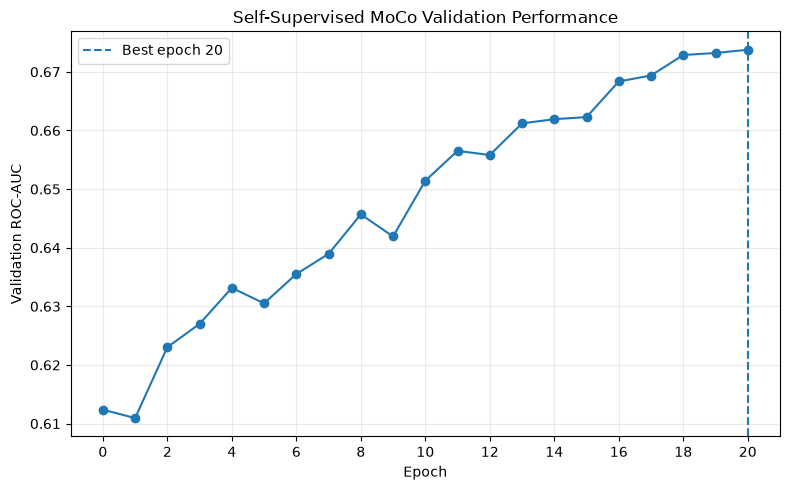

training_history.csv : True
verification_condition_results.csv : True
script_family_summary.csv : True
representation_comparison.csv : True
ssl_dynamic_script_gap_comparison.csv : True
ssl_summary.json : True
validation_auc_training_curve.png : True

Best SSL epoch: 20
Validation ROC-AUC: 0.673769
Official-test ROC-AUC: 0.692327
Validation script gap: 0.059
Official-test script gap: 0.1011
Skipped optimizer steps: 0


In [13]:
TRAINING_HISTORY_PATH = (
    REPORT_DIR
    / "training_history.csv"
)

CONDITION_RESULTS_PATH = (
    REPORT_DIR
    / "verification_condition_results.csv"
)

SCRIPT_FAMILY_PATH = (
    REPORT_DIR
    / "script_family_summary.csv"
)

REPRESENTATION_COMPARISON_PATH = (
    REPORT_DIR
    / "representation_comparison.csv"
)

SCRIPT_GAP_COMPARISON_PATH = (
    REPORT_DIR
    / "ssl_dynamic_script_gap_comparison.csv"
)

SUMMARY_PATH = (
    REPORT_DIR
    / "ssl_summary.json"
)

TRAINING_CURVE_PATH = (
    REPORT_DIR
    / "validation_auc_training_curve.png"
)

training_history_df.to_csv(
    TRAINING_HISTORY_PATH,
    index=False,
)

ssl_condition_results_df.to_csv(
    CONDITION_RESULTS_PATH,
    index=False,
)

ssl_script_family_df.to_csv(
    SCRIPT_FAMILY_PATH,
    index=False,
)

representation_comparison_df.to_csv(
    REPRESENTATION_COMPARISON_PATH,
    index=False,
)

ssl_dynamic_gap_comparison_df.to_csv(
    SCRIPT_GAP_COMPARISON_PATH,
    index=False,
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    training_history_df[
        "epoch"
    ],
    training_history_df[
        "validation_roc_auc"
    ],
    marker="o",
)

ax.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch {best_epoch}",
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "Validation ROC-AUC"
)

ax.set_title(
    "Self-Supervised MoCo Validation Performance"
)

ax.set_xticks(
    range(
        0,
        SSL_EPOCHS + 1,
        2,
    )
)

ax.grid(
    alpha=0.25
)

ax.legend()

fig.tight_layout()

fig.savefig(
    TRAINING_CURVE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

validation_ssl_gap = (
    ssl_gap_comparison_df.loc[
        ssl_gap_comparison_df[
            "experiment_split"
        ] == "validation",
        "within_minus_cross_auc_gap",
    ].iloc[0]
)

test_ssl_gap = (
    ssl_gap_comparison_df.loc[
        ssl_gap_comparison_df[
            "experiment_split"
        ] == "official_test",
        "within_minus_cross_auc_gap",
    ].iloc[0]
)

ssl_summary = {
    "training": {
        "method": "moco_style_contrastive_learning",
        "writer_labels_used": False,
        "development_images": 904,
        "development_writers": 226,
        "epochs": SSL_EPOCHS,
        "best_epoch": int(
            best_epoch
        ),
        "batch_size": SSL_BATCH_SIZE,
        "projection_dim": PROJECTION_DIM,
        "queue_size": QUEUE_SIZE,
        "temperature": TEMPERATURE,
        "momentum": MOCO_MOMENTUM,
        "skipped_optimizer_steps": int(
            training_history_df[
                "skipped_steps"
            ].sum()
        ),
    },
    "validation": {
        "roc_auc": float(
            frozen_validation_metrics[
                "roc_auc"
            ]
        ),
        "eer_percent": float(
            frozen_validation_metrics[
                "eer_percent"
            ]
        ),
        "script_gap": float(
            validation_ssl_gap
        ),
    },
    "official_test_descriptive": {
        "roc_auc": float(
            test_metrics[
                "roc_auc"
            ]
        ),
        "eer_percent": float(
            test_metrics[
                "eer_percent"
            ]
        ),
        "script_gap": float(
            test_ssl_gap
        ),
    },
    "interpretation": {
        "improves_over_imagenet": True,
        "outperforms_supervised_metric_learning": False,
        "smaller_script_gap_than_dynamic_metric": True,
        "next_stage": (
            "initialize supervised metric learning "
            "from the self-supervised encoder"
        ),
    },
}

with SUMMARY_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        ssl_summary,
        file,
        indent=2,
    )

saved_paths = [
    TRAINING_HISTORY_PATH,
    CONDITION_RESULTS_PATH,
    SCRIPT_FAMILY_PATH,
    REPRESENTATION_COMPARISON_PATH,
    SCRIPT_GAP_COMPARISON_PATH,
    SUMMARY_PATH,
    TRAINING_CURVE_PATH,
]

for path in saved_paths:
    print(
        path.name,
        ":",
        path.exists(),
    )

print()
print(
    "Best SSL epoch:",
    best_epoch,
)

print(
    "Validation ROC-AUC:",
    round(
        frozen_validation_metrics[
            "roc_auc"
        ],
        6,
    ),
)

print(
    "Official-test ROC-AUC:",
    round(
        test_metrics[
            "roc_auc"
        ],
        6,
    ),
)

print(
    "Validation script gap:",
    round(
        validation_ssl_gap,
        4,
    ),
)

print(
    "Official-test script gap:",
    round(
        test_ssl_gap,
        4,
    ),
)

print(
    "Skipped optimizer steps:",
    int(
        training_history_df[
            "skipped_steps"
        ].sum()
    ),
)

## Self-supervised pretraining conclusion

This experiment evaluated whether unlabeled handwriting-domain adaptation can improve writer-verification representations without using writer identities during representation learning.

A MoCo-style contrastive objective was trained on all 904 development-training images from 226 writers, covering both Arabic and English and both variable-text and same-text pages.

Writer labels were not used by the self-supervised objective.

The ResNet-18 encoder started from the same ImageNet initialization used in the previous experiments, allowing a controlled comparison with the original pretrained representation.

### Training behavior

Self-supervised training remained numerically stable for all 20 epochs.

- No optimizer steps were skipped
- Validation ROC-AUC generally increased throughout training
- The best validation checkpoint occurred at the predeclared final epoch, epoch 20
- Validation ROC-AUC increased from 0.6124 at initialization to 0.6738
- Validation EER decreased from 43.15% to 38.99%

The best epoch occurring at the training boundary suggests that the representation had not necessarily converged fully within 20 epochs.

However, the 20-epoch experiment is kept frozen rather than extending training after inspecting its evaluation results.

### Aggregate writer-verification performance

Compared with the original ImageNet representation:

- Validation ROC-AUC improved from 0.6124 to 0.6738
- Official-test ROC-AUC improved from 0.6353 to 0.6923
- Validation AUC gain was approximately 0.0614
- Official-test AUC gain was approximately 0.0570

This demonstrates that unlabeled handwriting-domain adaptation learned representation features that are substantially more useful for writer verification than the original ImageNet representation.

However, standalone self-supervised learning remained below supervised metric learning.

Compared with writer-aware dynamic metric learning:

- Validation ROC-AUC was lower by approximately 0.0682
- Official-test ROC-AUC was lower by approximately 0.0718

Therefore, writer supervision remains highly valuable for discrimination between writers.

### Script-condition behavior

The self-supervised representation showed:

Validation:

- Within-script macro ROC-AUC: 0.7281
- Cross-script macro ROC-AUC: 0.6691
- Within-minus-cross AUC gap: 0.0590

Official test:

- Within-script macro ROC-AUC: 0.7723
- Cross-script macro ROC-AUC: 0.6712
- Within-minus-cross AUC gap: 0.1011

These gaps are smaller than those observed with dynamic supervised metric learning:

- Validation dynamic-metric gap: 0.1256
- Official-test dynamic-metric gap: 0.1274

This is an important observation, but it is not sufficient evidence of script invariance.

A smaller within-versus-cross gap can arise partly because the self-supervised representation has lower overall writer-discrimination performance. Explicit script-prediction and content-leakage experiments are required before concluding that the representation contains less script information.

### Main finding

The self-supervised experiment establishes three important results.

First, handwriting-domain self-supervision provides a substantial improvement over generic ImageNet features without using writer labels.

Second, standalone self-supervision does not match supervised metric learning for writer discrimination.

Third, the smaller observed within-versus-cross performance gap motivates testing whether self-supervised initialization can preserve transferable handwriting structure while writer-supervised metric learning adds stronger identity discrimination.

### Next research stage

The next controlled experiment should initialize supervised metric learning from the self-supervised epoch-20 encoder instead of directly from ImageNet.

The central question becomes:

**Can self-supervised handwriting pretraining followed by writer-supervised metric learning combine stronger writer discrimination with better cross-script generalization?**

This hybrid experiment should retain the same writer-disjoint validation protocol and use validation-only model selection.

The official-test split should remain descriptive and must not be used to choose hybrid-training hyperparameters or checkpoints.

In [14]:
print(
    "SSL writer labels used:",
    ssl_summary[
        "training"
    ][
        "writer_labels_used"
    ],
)

print(
    "Best SSL epoch:",
    ssl_summary[
        "training"
    ][
        "best_epoch"
    ],
)

print(
    "ImageNet → SSL validation AUC:",
    round(
        0.612379,
        6,
    ),
    "→",
    round(
        frozen_validation_metrics[
            "roc_auc"
        ],
        6,
    ),
)

print(
    "ImageNet → SSL official-test AUC:",
    round(
        0.6353,
        4,
    ),
    "→",
    round(
        test_metrics[
            "roc_auc"
        ],
        6,
    ),
)

print(
    "SSL validation script gap:",
    round(
        validation_ssl_gap,
        4,
    ),
)

print(
    "SSL official-test script gap:",
    round(
        test_ssl_gap,
        4,
    ),
)

print(
    "Dynamic metric validation script gap:",
    0.1256,
)

print(
    "Dynamic metric official-test script gap:",
    0.1274,
)

print(
    "Standalone SSL beats ImageNet:",
    True,
)

print(
    "Standalone SSL beats supervised metric learning:",
    False,
)

print(
    "Script invariance established:",
    False,
)

print(
    "Skipped optimizer steps:",
    ssl_summary[
        "training"
    ][
        "skipped_optimizer_steps"
    ],
)

print(
    "Notebook 13 complete:",
    True,
)

SSL writer labels used: False
Best SSL epoch: 20
ImageNet → SSL validation AUC: 0.612379 → 0.673769
ImageNet → SSL official-test AUC: 0.6353 → 0.692327
SSL validation script gap: 0.059
SSL official-test script gap: 0.1011
Dynamic metric validation script gap: 0.1256
Dynamic metric official-test script gap: 0.1274
Standalone SSL beats ImageNet: True
Standalone SSL beats supervised metric learning: False
Script invariance established: False
Skipped optimizer steps: 0
Notebook 13 complete: True
